In [ ]:
Load Data from GitHub

In [1]:
import pandas as pd
import numpy as np

github_url = "https://raw.githubusercontent.com/tarshibofficial/Ai-ML-Assignment-3/main/Dataset/diabetes%20%281%29%20%281%29.csv"

df = pd.read_csv(github_url)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dataset Information

In [2]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

Missing Values:
Pregnancies  

Separate Features and Target

In [3]:
if 'Outcome' in df.columns:
    target_col = 'Outcome'
else:
    target_col = df.columns[-1]

X = df.drop(target_col, axis=1)
y = df[target_col]

print("Target column:", target_col)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

X.head()

Target column: Outcome
Features shape: (768, 8)
Target shape: (768,)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


Target Distribution

In [4]:
target_names = ['No Diabetes', 'Diabetes']

print("\nTarget distribution:")
print(y.value_counts())

print("\nClass Balance:")
for i, name in enumerate(target_names):
    count = (y == i).sum()
    percentage = (count / len(y)) * 100
    print(f"  {name}: {count} ({percentage:.2f}%)")


Target distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Class Balance:
  No Diabetes: 500 (65.10%)
  Diabetes: 268 (34.90%)


Feature Scaling

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496


Elbow Method

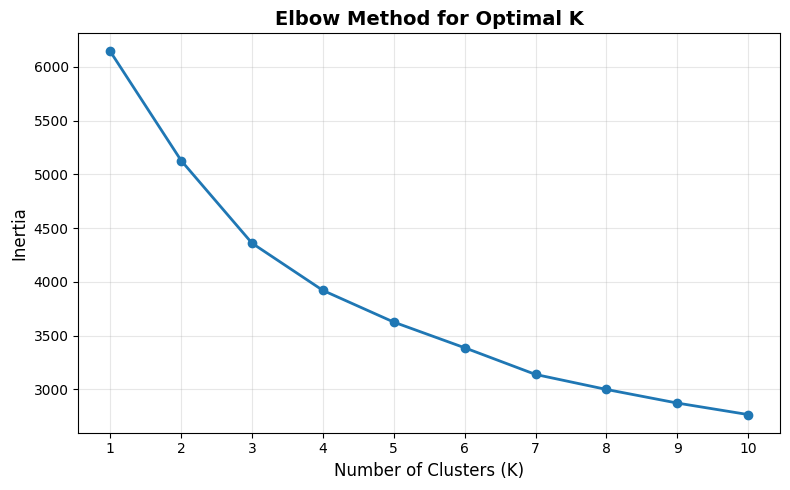

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia_values = []

k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', linewidth=2)

plt.title('Elbow Method for Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.xticks(k_range)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('1_Elbow_Method.png', dpi=300, bbox_inches='tight')
plt.show()

Silhouette Score Analysis

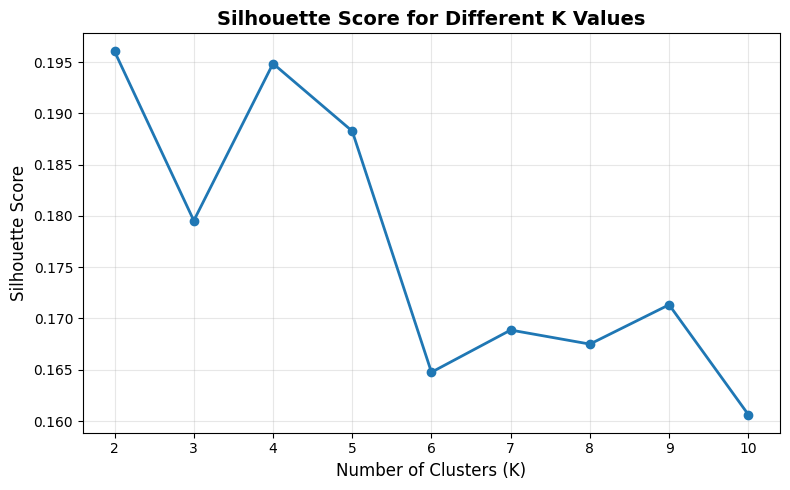

Best K based on Silhouette Score: 2
Best Silhouette Score: 0.1960


In [7]:
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linewidth=2)

plt.title('Silhouette Score for Different K Values', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(k_range)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('2_Silhouette_Score.png', dpi=300, bbox_inches='tight')
plt.show()

best_k = list(k_range)[np.argmax(silhouette_scores)]
best_silhouette = max(silhouette_scores)

print(f"Best K based on Silhouette Score: {best_k}")
print(f"Best Silhouette Score: {best_silhouette:.4f}")

K-Means Implementation

In [8]:
kmeans_model = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans_model.fit_predict(X_scaled)

df_clustered = df.copy()
df_clustered['Cluster'] = cluster_labels

print("K-Means Clustering Complete!")
print("\nCluster Labels:")
print(df_clustered['Cluster'].value_counts())

df_clustered.head()

K-Means Clustering Complete!

Cluster Labels:
Cluster
1    498
0    270
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,0
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,0
3,1,89,66,23,94,28.1,0.167,21,0,1
4,0,137,40,35,168,43.1,2.288,33,1,1


Cluster Distribution

In [9]:
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()

print("Cluster Distribution:")
for cluster, count in cluster_counts.items():
    percentage = (count / len(df_clustered)) * 100
    print(f"  Cluster {cluster}: {count} ({percentage:.2f}%)")

Cluster Distribution:
  Cluster 0: 270 (35.16%)
  Cluster 1: 498 (64.84%)


Compare Clusters with Actual Outcome

In [10]:
comparison_table = pd.crosstab(
    df_clustered['Cluster'],
    df_clustered[target_col],
    rownames=['Cluster'],
    colnames=['Actual Outcome']
)

print("Cluster vs Actual Outcome:")
print(comparison_table)

Cluster vs Actual Outcome:
Actual Outcome    0    1
Cluster                 
0               126  144
1               374  124


Clustering Evaluation Metrics

In [12]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score
)

kmeans_silhouette = silhouette_score(X_scaled, cluster_labels)
kmeans_davies = davies_bouldin_score(X_scaled, cluster_labels)
kmeans_calinski = calinski_harabasz_score(X_scaled, cluster_labels)
kmeans_ari = adjusted_rand_score(y, cluster_labels)

print("\n--- K-Means Clustering Metrics ---")
print(f"Silhouette Score:        {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score:    {kmeans_davies:.4f}")
print(f"Calinski-Harabasz Score: {kmeans_calinski:.4f}")
print(f"Adjusted Rand Index:     {kmeans_ari:.4f}")


--- K-Means Clustering Metrics ---
Silhouette Score:        0.1960
Davies-Bouldin Score:    2.0118
Calinski-Harabasz Score: 151.6215
Adjusted Rand Index:     0.1137


Cluster Visualization using PCA

In [13]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['Cluster'] = cluster_labels
pca_df['Outcome'] = y.values

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

pca_df.head()

Explained Variance Ratio:
[0.26179749 0.21640127]


,PC1,PC2,Cluster,Outcome
0,1.068503,1.234895,0,1
1,-1.121683,-0.733852,1,0
2,-0.396477,1.595876,0,1
3,-1.115781,-1.271241,1,0
4,2.359334,-2.184819,1,1


K-Means Cluster Visualization

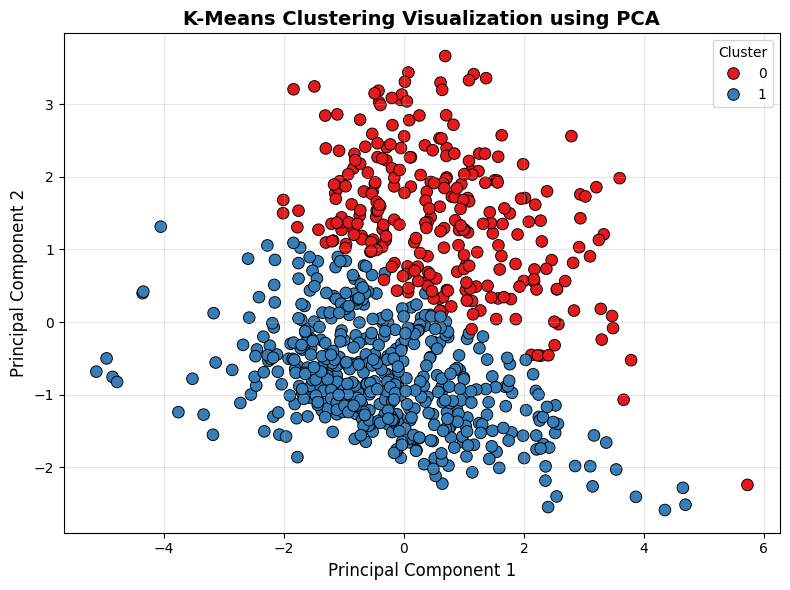

In [14]:
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=70,
    edgecolor='black'
)

plt.title('K-Means Clustering Visualization using PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('3_KMeans_Cluster_Visualization.png', dpi=300, bbox_inches='tight')
plt.show()

Actual Outcome Visualization using PCA

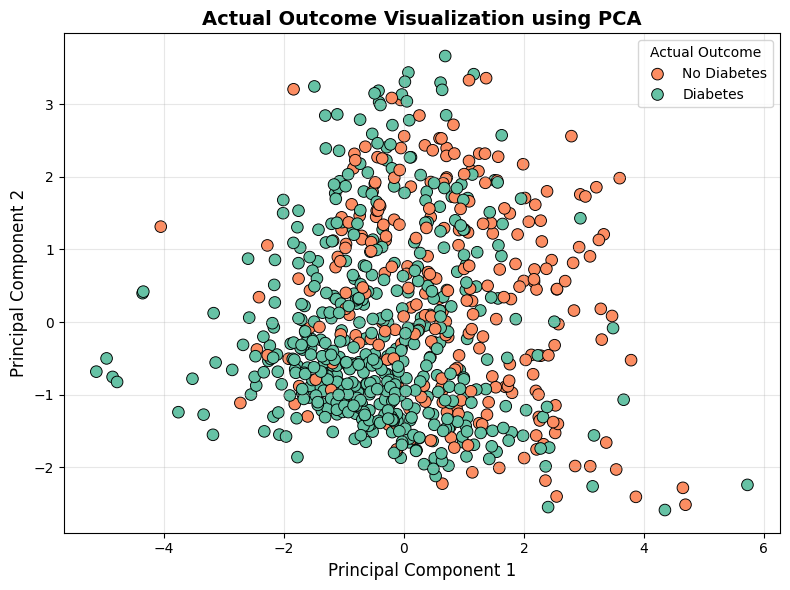

In [15]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Outcome',
    palette='Set2',
    s=70,
    edgecolor='black'
)

plt.title('Actual Outcome Visualization using PCA', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Actual Outcome', labels=target_names)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('4_Actual_Outcome_Visualization.png', dpi=300, bbox_inches='tight')
plt.show()

Cluster vs Actual Outcome Heatmap

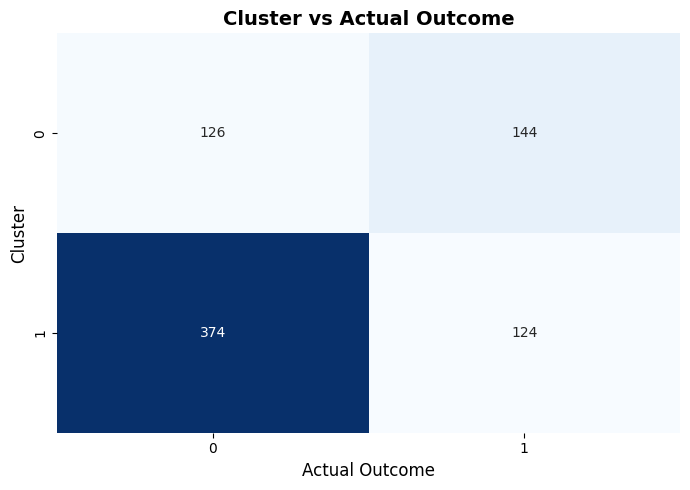

In [16]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    comparison_table,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('Cluster vs Actual Outcome', fontsize=14, fontweight='bold')
plt.xlabel('Actual Outcome', fontsize=12)
plt.ylabel('Cluster', fontsize=12)

plt.tight_layout()
plt.savefig('5_Cluster_vs_Actual_Outcome.png', dpi=300, bbox_inches='tight')
plt.show()

Cluster Centers

In [17]:
cluster_centers_scaled = kmeans_model.cluster_centers_

cluster_centers_original = scaler.inverse_transform(cluster_centers_scaled)

cluster_centers_df = pd.DataFrame(
    cluster_centers_original,
    columns=X.columns
)

cluster_centers_df.index = ['Cluster 0', 'Cluster 1']

print("Cluster Centers in Original Scale:")
display(cluster_centers_df)

Cluster Centers in Original Scale:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Cluster 0,7.085185,134.592593,77.040741,18.103704,75.411111,32.930000,0.481037,45.681481
Cluster 1,2.088353,113.467871,64.803213,21.855422,82.178715,31.484337,0.466910,26.495984


Cluster Centers Visualization

<Figure size 1200x600 with 0 Axes>

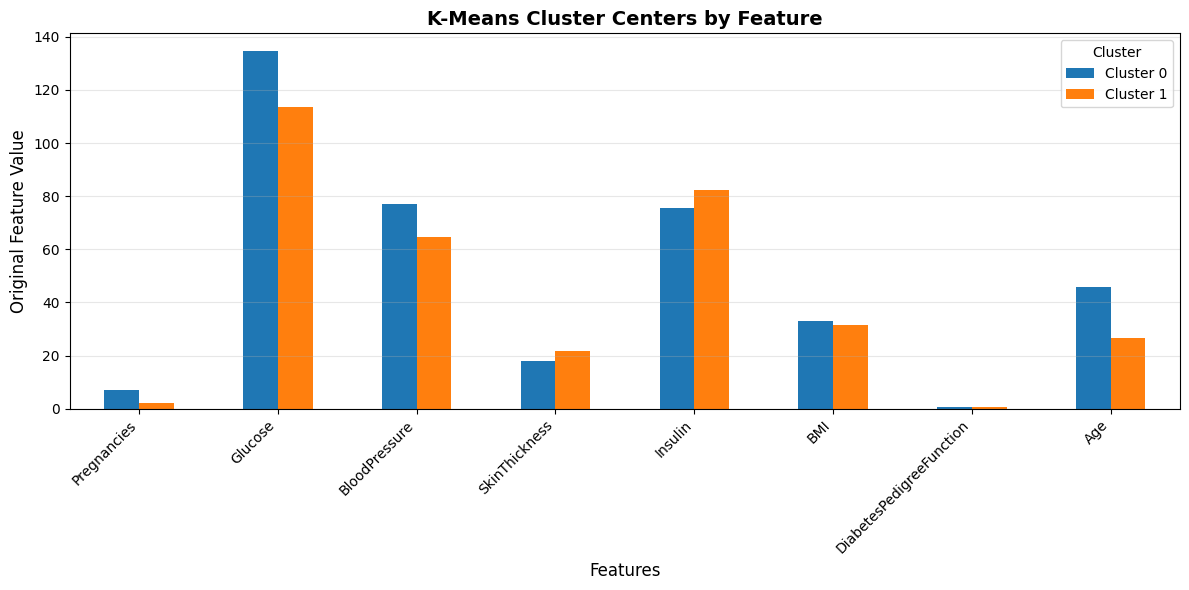

In [18]:
plt.figure(figsize=(12, 6))

cluster_centers_df.T.plot(kind='bar', figsize=(12, 6))

plt.title('K-Means Cluster Centers by Feature', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Original Feature Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Cluster')

plt.tight_layout()
plt.savefig('6_Cluster_Centers.png', dpi=300, bbox_inches='tight')
plt.show()

Final Clustering Summary

In [19]:
summary_df = pd.DataFrame({
    'Metric': [
        'Number of Clusters',
        'Silhouette Score',
        'Davies-Bouldin Score',
        'Calinski-Harabasz Score',
        'Adjusted Rand Index'
    ],
    'Value': [
        2,
        round(kmeans_silhouette, 4),
        round(kmeans_davies, 4),
        round(kmeans_calinski, 4),
        round(kmeans_ari, 4)
    ]
})

print("K-Means Clustering Summary:")
display(summary_df)

print("\nInterpretation:")
print("K-Means created 2 clusters from the diabetes dataset without using the Outcome column.")
print("The clusters were compared with the actual diabetes outcome only after clustering.")
print("Because K-Means is unsupervised, cluster numbers do not directly mean No Diabetes or Diabetes.")

K-Means Clustering Summary:


,Metric,Value
0,Number of Clusters,2.0000
1,Silhouette Score,0.1960
2,Davies-Bouldin Score,2.0118
3,Calinski-Harabasz Score,151.6215
4,Adjusted Rand Index,0.1137



Interpretation:
K-Means created 2 clusters from the diabetes dataset without using the Outcome column.
The clusters were compared with the actual diabetes outcome only after clustering.
Because K-Means is unsupervised, cluster numbers do not directly mean No Diabetes or Diabetes.


Save Final Dataset with Cluster Labels

In [20]:
df_clustered.to_csv('diabetes_kmeans_clustered.csv', index=False)

print("Clustered dataset saved as: diabetes_kmeans_clustered.csv")
df_clustered.head()

Clustered dataset saved as: diabetes_kmeans_clustered.csv


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Cluster
0,6,148,72,35,0,33.6,0.627,50,1,0
1,1,85,66,29,0,26.6,0.351,31,0,1
2,8,183,64,0,0,23.3,0.672,32,1,0
3,1,89,66,23,94,28.1,0.167,21,0,1
4,0,137,40,35,168,43.1,2.288,33,1,1
